### **Анализ системы с приоритетами**

**Цель работы:**
Исследовать характеристики системы массового обслуживания с приоритетами и проанализировать влияние приоритетов на время ожидания и эффективность системы.

**Задачи:**

1. Разработать математическую модель системы с приоритетами.
2. Провести расчёты основных характеристик системы для различных классов заявок.
3. Проанализировать влияние приоритетов на время ожидания и эффективность системы.

**Исходные данные:**

- Интенсивность входящего потока заявок:
    - Высокоприоритетные заявки (λ₁): 3 заявки/час.
    - Низкоприоритетные заявки (λ₂): 5 заявок/час.
- Интенсивность обслуживания (μ): 10 заявок/час.
- Тип приоритета: абсолютный (высокоприоритетные заявки обслуживаются в первую очередь).

### Шаг 1. Разработка модели

_Опишите систему массового обслуживания с двумя классами заявок: высокоприоритетные и низкоприоритетные._

_Учтите, что высокоприоритетные заявки обслуживаются в первую очередь, независимо от наличия низкоприоритетных заявок в очереди._

**МФЦ** — многофункциональный центр с одним сотрудником. Посетители делятся на два класса:
- **Класс 1 (высокоприоритетные):** льготники, ветераны, инвалиды — обслуживаются вне очереди (λ₁ = 3 чел/час).
- **Класс 2 (низкоприоритетные):** обычные посетители — обслуживаются только при отсутствии посетителей класса 1 (λ₂ = 5 чел/час).

Нотация: **M/M/1 с абсолютными приоритетами**
- **M** — пуассоновский входящий поток для каждого класса
- **M** — экспоненциальное время обслуживания (одинаковое для обоих классов)
- **1** — один сотрудник (канал)
- **Абсолютный приоритет** — посетитель класса 1, застав сотрудника занятым посетителем класса 2, вытесняет его: обслуживание класса 2 прерывается и возобновляется позже

Работа системы:
1. Посетитель приходит.
2. Если сотрудник свободен — обслуживание начинается немедленно.
3. Если занят посетителем **того же или более высокого** приоритета — новый посетитель встаёт в хвост своей очереди.
4. Если посетитель класса 1 застаёт сотрудника за обслуживанием класса 2 — обслуживание класса 2 **прерывается** (вытеснение), класс 2 возвращается в начало своей очереди.
5. Когда сотрудник освобождается, он берёт первого из очереди класса 1; если она пуста — первого из очереди класса 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import heapq
from IPython.display import display

np.random.seed(42)

ARRIVAL_RATE_HIGH_PRIORITY = 3  # λ₁ — высокоприоритетные, чел/час
ARRIVAL_RATE_LOW_PRIORITY = 5   # λ₂ — низкоприоритетные, чел/час
SERVICE_RATE = 10               # μ — заявок/час
SIMULATION_TIME = 5000          # T — часов

### Шаг 2. Расчёт характеристик системы

_Рассчитайте следующие показатели для каждого класса заявок:_
- _Среднее время ожидания в очереди._
- _Среднее время пребывания в системе._
- _Вероятность того, что заявка будет ждать в очереди._

_Рассчитайте общие характеристики системы:_
- _Коэффициент загрузки системы._
- _Среднее число заявок в системе._

Используем событийное моделирование с **абсолютными вытесняющими приоритетами**. Реализованы три типа событий: **прибытие класса 1**, **прибытие класса 2**, **окончание обслуживания**.

Ключевое правило: когда приходит посетитель класса 1 и сотрудник занят классом 2, текущее обслуживание **прерывается** — оставшееся время обслуживания сохраняется и будет использовано при возобновлении.

Все показатели вычисляются из данных симуляции:

| Величина | Формула | Смысл |
|---|---|---|
| $\hat{W}_{q,i}$ | $\dfrac{\sum w_k^{(i)}}{N_i}$ | Ср. время ожидания для класса $i$ |
| $\hat{W}_i$ | $\hat{W}_{q,i} + \dfrac{1}{\mu}$ | Ср. время в МФЦ для класса $i$ |
| $\hat{\rho}$ | $\dfrac{\text{время занятости}}{T}$ | Коэффициент загрузки сотрудника |
| $\hat{L}$ | $\lambda_{\text{eff}} \cdot \hat{W}$ | Ср. число посетителей в системе (з. Литтла) |
| $\hat{P}_{\text{wait},i}$ | $\dfrac{N_i^{\text{ждал}}}{N_i}$ | Доля посетителей класса $i$, ожидавших в очереди |

In [2]:
def simulate_priority(lam1, lam2, mu, T):
    """
    Типы событий в куче:
        0  — приход заявки класса 1
        1  — приход заявки класса 2
        2  — окончание обслуживания
       -1  — отменённое событие (после вытеснения)
    """
    queue1 = []   # очередь класса 1: (время_прихода)
    queue2 = []   # очередь класса 2: (время_прихода)

    server_busy   = False
    current_class = None   # 1 или 2
    service_end   = None   # время окончания текущего обслуживания

    events = []
    heapq.heappush(events, (np.random.exponential(1 / lam1), 0))
    heapq.heappush(events, (np.random.exponential(1 / lam2), 1))

    n1_arrived = n2_arrived = 0
    n1_served  = n2_served  = 0
    sum_wait1  = sum_wait2  = 0.0
    n1_waited  = n2_waited  = 0
    busy_time  = 0.0
    area_q1    = area_q2    = 0.0
    last_t     = 0.0

    while events:
        t, etype = heapq.heappop(events)
        if t > T:
            break

        dt = t - last_t
        area_q1 += len(queue1) * dt
        area_q2 += len(queue2) * dt
        last_t = t

        # Приход заявки класса 1
        if etype == 0:
            heapq.heappush(events, (t + np.random.exponential(1 / lam1), 0))
            n1_arrived += 1

            if not server_busy:
                # сотрудник свободен — обслуживаем сразу
                server_busy   = True
                current_class = 1
                svc           = np.random.exponential(1 / mu)
                busy_time    += svc
                service_end   = t + svc
                heapq.heappush(events, (service_end, 2))

            elif current_class == 2:
                # Вытесняем класс 2: сохраняем оставшееся время и кладём его в начало очереди
                rem           = max(0.0, service_end - t)
                cancelled_end = service_end
                queue2.insert(0, (None, rem))
                current_class = 1
                svc           = np.random.exponential(1 / mu)
                busy_time    += svc
                service_end   = t + svc
                heapq.heappush(events, (service_end, 2))
                # Старое событие окончания больше не актуально
                heapq.heappush(events, (cancelled_end, -1))

            else:
                # сотрудник занят классом 1 — встаём в очередь своего класса
                queue1.append((t,))

        # Приход заявки класса 2
        elif etype == 1:
            heapq.heappush(events, (t + np.random.exponential(1 / lam2), 1))
            n2_arrived += 1

            if not server_busy:
                server_busy   = True
                current_class = 2
                svc           = np.random.exponential(1 / mu)
                busy_time    += svc
                service_end   = t + svc
                heapq.heappush(events, (service_end, 2))
            else:
                # Класс 2 всегда встаёт в хвост, независимо от того, кто обслуживается
                queue2.append((t,))

        # Окончание обслуживания
        elif etype == 2:
            # Проверяем, не было ли это событие отменено вытеснением
            if t != service_end:
                continue

            if current_class == 1:
                n1_served += 1
            else:
                n2_served += 1

            # Следующая заявка: класс 1 имеет приоритет
            if queue1:
                (arr_time,) = queue1.pop(0)
                wait = t - arr_time
                sum_wait1 += wait
                if wait > 1e-9:
                    n1_waited += 1
                current_class = 1
                svc           = np.random.exponential(1 / mu)
                busy_time    += svc
                service_end   = t + svc
                heapq.heappush(events, (service_end, 2))

            elif queue2:
                entry = queue2.pop(0)
                if len(entry) == 1:
                    # Обычная заявка класса 2
                    arr_time = entry[0]
                    wait = t - arr_time
                    sum_wait2 += wait
                    if wait > 1e-9:
                        n2_waited += 1
                    svc        = np.random.exponential(1 / mu)
                    busy_time += svc
                else:
                    # Вытесненная заявка: оставшееся время уже учтено в busy_time
                    svc = entry[1]
                current_class = 2
                service_end   = t + svc
                heapq.heappush(events, (service_end, 2))

            else:
                server_busy   = False
                current_class = None
                service_end   = None

    rho    = busy_time / T
    Wq1    = sum_wait1 / n1_arrived if n1_arrived else 0
    Wq2    = sum_wait2 / n2_arrived if n2_arrived else 0
    W1     = Wq1 + 1 / mu
    W2     = Wq2 + 1 / mu
    Lq1    = area_q1 / T
    Lq2    = area_q2 / T
    Pwait1 = n1_waited / n1_arrived if n1_arrived else 0
    Pwait2 = n2_waited / n2_arrived if n2_arrived else 0
    L      = lam1 * W1 + lam2 * W2

    return {
        "n1_arrived": n1_arrived,
        "n2_arrived": n2_arrived,
        "n1_served":  n1_served,
        "n2_served":  n2_served,
        "rho":        round(rho,    4),
        "Wq1 (ч)":   round(Wq1,    4),
        "Wq2 (ч)":   round(Wq2,    4),
        "W1  (ч)":   round(W1,     4),
        "W2  (ч)":   round(W2,     4),
        "Lq1":        round(Lq1,    4),
        "Lq2":        round(Lq2,    4),
        "L":          round(L,      4),
        "P_wait1":    round(Pwait1, 4),
        "P_wait2":    round(Pwait2, 4),
    }


result = simulate_priority(ARRIVAL_RATE_HIGH_PRIORITY, ARRIVAL_RATE_LOW_PRIORITY, SERVICE_RATE, SIMULATION_TIME)

print(f"Результаты симуляции (λ₁={ARRIVAL_RATE_HIGH_PRIORITY}, λ₂={ARRIVAL_RATE_LOW_PRIORITY}, μ={SERVICE_RATE}):")
print()
print(f"  Пришло (кл. 1 / кл. 2):    {result['n1_arrived']} / {result['n2_arrived']}")
print(f"  Обслужено (кл. 1 / кл. 2): {result['n1_served']} / {result['n2_served']}")
print()
for key in ["rho", "Wq1 (ч)", "Wq2 (ч)", "W1  (ч)", "W2  (ч)",
            "Lq1", "Lq2", "L", "P_wait1", "P_wait2"]:
    print(f"  {key:20s}: {result[key]}")

Результаты симуляции (λ₁=3, λ₂=5, μ=10):

  Пришло (кл. 1 / кл. 2):    14990 / 24996
  Обслужено (кл. 1 / кл. 2): 14990 / 24996

  rho                 : 0.7936
  Wq1 (ч)             : 0.0413
  Wq2 (ч)             : 0.5144
  W1  (ч)             : 0.1413
  W2  (ч)             : 0.6144
  Lq1                 : 0.1239
  Lq2                 : 2.7799
  L                   : 3.4959
  P_wait1             : 0.2909
  P_wait2             : 0.797


### Шаг 3. Сравнение экспериментальных значений с теоретическими

_Сравните результаты симуляции с теоретическими формулами для системы M/M/1 с абсолютными приоритетами._

_Рассчитайте относительное отклонение для каждого показателя._

**Теоретические формулы** для M/M/1 с абсолютными вытесняющими приоритетами:

Общий коэффициент загрузки:
$$\rho = \frac{\lambda_1 + \lambda_2}{\mu}, \quad \rho_i = \frac{\lambda_i}{\mu}$$

Среднее время ожидания в очереди:
$$W_{q,1} = \frac{\rho_1/\mu}{1 - \rho_1}, \quad W_{q,2} = \frac{\rho/\mu}{(1 - \rho_1)(1 - \rho)}$$

Среднее время в системе:
$$W_i = W_{q,i} + \frac{1}{\mu}$$

Вероятность ожидания:
$$P_{\text{wait},1} = \rho_1, \quad P_{\text{wait},2} = \rho$$

Среднее число заявок в очереди (закон Литтла):
$$L_{q,i} = \lambda_i \cdot W_{q,i}, \quad L = \lambda_1 W_1 + \lambda_2 W_2$$

In [3]:
def mm1_priority_theory(lam1, lam2, mu):
    """
    Класс 1 не зависит от класса 2: он видит систему как обычный M/M/1
    только со своей нагрузкой ρ₁. Формула для класса 2 учитывает и свою
    нагрузку, и вытеснения со стороны класса 1.
    """
    rho  = (lam1 + lam2) / mu
    rho1 = lam1 / mu

    Wq1 = (rho1 / mu) / (1 - rho1)
    Wq2 = (rho  / mu) / ((1 - rho1) * (1 - rho))

    W1  = Wq1 + 1 / mu
    W2  = Wq2 + 1 / mu

    Lq1 = lam1 * Wq1
    Lq2 = lam2 * Wq2
    L   = lam1 * W1 + lam2 * W2

    # Класс 1 ждёт только когда сотрудник занят другим клиентом класса 1
    # Класс 2 ждёт всегда, когда сотрудник хоть чем-то занят
    Pwait1 = rho1
    Pwait2 = rho

    return {
        "rho":      round(rho,    4),
        "Wq1 (ч)": round(Wq1,    4),
        "Wq2 (ч)": round(Wq2,    4),
        "W1  (ч)": round(W1,     4),
        "W2  (ч)": round(W2,     4),
        "Lq1":      round(Lq1,    4),
        "Lq2":      round(Lq2,    4),
        "L":        round(L,      4),
        "P_wait1":  round(Pwait1, 4),
        "P_wait2":  round(Pwait2, 4),
    }


theory = mm1_priority_theory(ARRIVAL_RATE_HIGH_PRIORITY, ARRIVAL_RATE_LOW_PRIORITY, SERVICE_RATE)
sim    = simulate_priority(ARRIVAL_RATE_HIGH_PRIORITY, ARRIVAL_RATE_LOW_PRIORITY, SERVICE_RATE, SIMULATION_TIME)

keys = ["rho", "Wq1 (ч)", "Wq2 (ч)", "W1  (ч)", "W2  (ч)",
        "Lq1", "Lq2", "L", "P_wait1", "P_wait2"]

comparison = pd.DataFrame({
    "Теория":    [theory[k] for k in keys],
    "Симуляция": [sim[k]    for k in keys],
}, index=keys)

comparison["Δ, %"] = (
    (comparison["Симуляция"] - comparison["Теория"]) / comparison["Теория"] * 100
).round(2)

print("Сравнение теоретических и экспериментальных значений:")
print()
print(comparison.round(4))

Сравнение теоретических и экспериментальных значений:

         Теория  Симуляция  Δ, %
rho      0.8000     0.7983 -0.21
Wq1 (ч)  0.0429     0.0452  5.36
Wq2 (ч)  0.5714     0.5465 -4.36
W1  (ч)  0.1429     0.1452  1.61
W2  (ч)  0.6714     0.6465 -3.71
Lq1      0.1286     0.1354  5.29
Lq2      2.8571     2.9340  2.69
L        3.7857     3.6682 -3.10
P_wait1  0.3000     0.3090  3.00
P_wait2  0.8000     0.7928 -0.90


### Шаг 4. Анализ влияния приоритетов

_Постройте графики зависимости времени ожидания от интенсивности входящего потока для каждого класса заявок._

_Сравните время ожидания и время пребывания для высокоприоритетных и низкоприоритетных заявок._

_Сделайте выводы о влиянии приоритетов на эффективность системы._

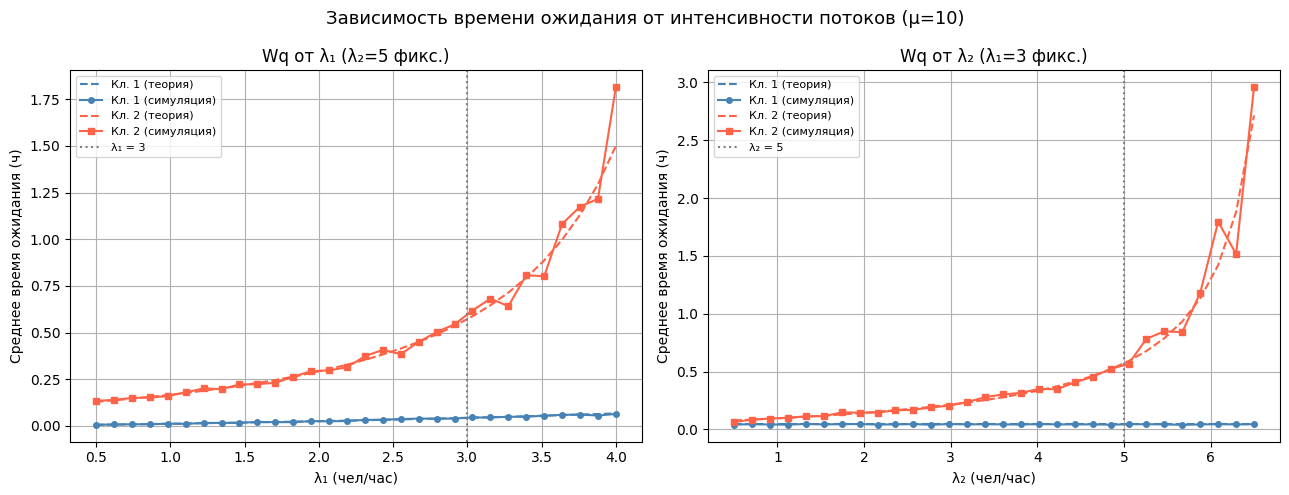

In [4]:
# График 1: как меняется Wq при росте λ₁ (λ₂ фиксировано)
lam2_fixed  = ARRIVAL_RATE_LOW_PRIORITY
lam1_values = np.linspace(0.5, 4.0, 30)  # λ₁ до 4, чтобы ρ оставалась < 1

wq1_th, wq2_th     = [], []
wq1_sim, wq2_sim   = [], []
lam1_used          = []

for l1 in lam1_values:
    if (l1 + lam2_fixed) / SERVICE_RATE >= 1:
        continue
    lam1_used.append(l1)
    t = mm1_priority_theory(l1, lam2_fixed, SERVICE_RATE)
    wq1_th.append(t["Wq1 (ч)"])
    wq2_th.append(t["Wq2 (ч)"])
    s = simulate_priority(l1, lam2_fixed, SERVICE_RATE, 3000)
    wq1_sim.append(s["Wq1 (ч)"])
    wq2_sim.append(s["Wq2 (ч)"])

# График 2: как меняется Wq при росте λ₂ (λ₁ фиксировано)
lam1_fixed  = ARRIVAL_RATE_HIGH_PRIORITY
lam2_values = np.linspace(0.5, 6.5, 30)

wq1_th2, wq2_th2   = [], []
wq1_sim2, wq2_sim2 = [], []
lam2_used          = []

for l2 in lam2_values:
    if (lam1_fixed + l2) / SERVICE_RATE >= 1:
        continue
    lam2_used.append(l2)
    t = mm1_priority_theory(lam1_fixed, l2, SERVICE_RATE)
    wq1_th2.append(t["Wq1 (ч)"])
    wq2_th2.append(t["Wq2 (ч)"])
    s = simulate_priority(lam1_fixed, l2, SERVICE_RATE, 3000)
    wq1_sim2.append(s["Wq1 (ч)"])
    wq2_sim2.append(s["Wq2 (ч)"])

plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(lam1_used, wq1_th,  color="steelblue", linestyle="--",            label="Кл. 1 (теория)")
ax.plot(lam1_used, wq1_sim, color="steelblue", marker="o", markersize=4,  label="Кл. 1 (симуляция)")
ax.plot(lam1_used, wq2_th,  color="tomato",    linestyle="--",            label="Кл. 2 (теория)")
ax.plot(lam1_used, wq2_sim, color="tomato",    marker="s", markersize=4,  label="Кл. 2 (симуляция)")
ax.axvline(x=ARRIVAL_RATE_HIGH_PRIORITY, color="grey", linestyle=":", label=f"λ₁ = {ARRIVAL_RATE_HIGH_PRIORITY}")
ax.set_title("Wq от λ₁ (λ₂=5 фикс.)")
ax.set_xlabel("λ₁ (чел/час)")
ax.set_ylabel("Среднее время ожидания (ч)")
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
ax.plot(lam2_used, wq1_th2,  color="steelblue", linestyle="--",            label="Кл. 1 (теория)")
ax.plot(lam2_used, wq1_sim2, color="steelblue", marker="o", markersize=4,  label="Кл. 1 (симуляция)")
ax.plot(lam2_used, wq2_th2,  color="tomato",    linestyle="--",            label="Кл. 2 (теория)")
ax.plot(lam2_used, wq2_sim2, color="tomato",    marker="s", markersize=4,  label="Кл. 2 (симуляция)")
ax.axvline(x=ARRIVAL_RATE_LOW_PRIORITY, color="grey", linestyle=":", label=f"λ₂ = {ARRIVAL_RATE_LOW_PRIORITY}")
ax.set_title("Wq от λ₂ (λ₁=3 фикс.)")
ax.set_xlabel("λ₂ (чел/час)")
ax.set_ylabel("Среднее время ожидания (ч)")
ax.legend(fontsize=8)
ax.grid(True)

plt.suptitle(
    f"Зависимость времени ожидания от интенсивности потоков (μ={SERVICE_RATE})",
    fontsize=13
)
plt.tight_layout()
plt.show()

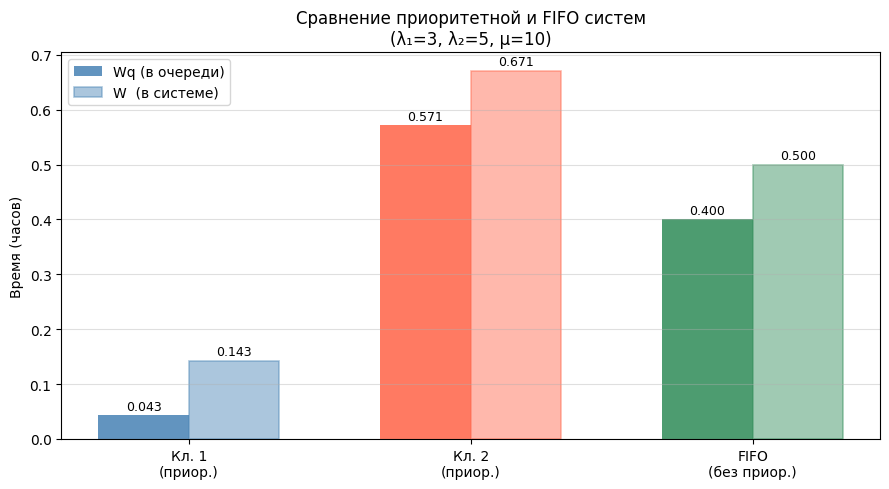


Теоретические значения:
  Wq1 (приоритет) = 0.0429 ч  (2.6 мин)
  Wq2 (приоритет) = 0.5714 ч  (34.3 мин)
  Wq  (FIFO)      = 0.4000 ч  (24.0 мин)
  Выигрыш кл.1 vs FIFO:    89.3%
  Проигрыш кл.2 vs FIFO:   42.8%


In [5]:
# Сравниваем приоритетную систему и FIFO на столбчатой диаграмме
theory_base = mm1_priority_theory(ARRIVAL_RATE_HIGH_PRIORITY, ARRIVAL_RATE_LOW_PRIORITY, SERVICE_RATE)

# FIFO M/M/1 без приоритетов: Wq = ρ / (μ(1 − ρ))
rho_base = (ARRIVAL_RATE_HIGH_PRIORITY + ARRIVAL_RATE_LOW_PRIORITY) / SERVICE_RATE
Wq_fifo  = rho_base / (SERVICE_RATE * (1 - rho_base))
W_fifo   = Wq_fifo + 1 / SERVICE_RATE

labels  = ["Кл. 1\n(приор.)", "Кл. 2\n(приор.)", "FIFO\n(без приор.)"]
Wq_vals = [theory_base["Wq1 (ч)"], theory_base["Wq2 (ч)"], round(Wq_fifo, 4)]
W_vals  = [theory_base["W1  (ч)"], theory_base["W2  (ч)"], round(W_fifo,  4)]
colors  = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(labels))
width = 0.32

bars_wq = ax.bar(x - width/2, Wq_vals, width, label="Wq (в очереди)",
                 color=colors, alpha=0.85)
bars_w  = ax.bar(x + width/2, W_vals,  width, label="W  (в системе)",
                 color=colors, alpha=0.45, edgecolor=colors, linewidth=1.2)

for bar, val in zip(bars_wq, Wq_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
for bar, val in zip(bars_w, W_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Время (часов)")
ax.set_title(
    f"Сравнение приоритетной и FIFO систем\n"
    f"(λ₁={ARRIVAL_RATE_HIGH_PRIORITY}, λ₂={ARRIVAL_RATE_LOW_PRIORITY}, μ={SERVICE_RATE})"
)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nТеоретические значения:")
print(f"  Wq1 (приоритет) = {theory_base['Wq1 (ч)']:.4f} ч  ({theory_base['Wq1 (ч)']*60:.1f} мин)")
print(f"  Wq2 (приоритет) = {theory_base['Wq2 (ч)']:.4f} ч  ({theory_base['Wq2 (ч)']*60:.1f} мин)")
print(f"  Wq  (FIFO)      = {Wq_fifo:.4f} ч  ({Wq_fifo*60:.1f} мин)")
print(f"  Выигрыш кл.1 vs FIFO:    {(Wq_fifo - theory_base['Wq1 (ч)']) / Wq_fifo * 100:.1f}%")
print(f"  Проигрыш кл.2 vs FIFO:   {(theory_base['Wq2 (ч)'] - Wq_fifo) / Wq_fifo * 100:.1f}%")

### Анализ результатов

#### Базовые параметры (λ₁=3, λ₂=5, μ=10)

Суммарная загрузка ρ = (λ₁ + λ₂)/μ = 0.8 — система устойчива. При этом ρ₁ = 0.3, ρ₂ = 0.5.

Симуляция (T=5000 ч) даёт Wq₁ ≈ 0.041 ч и Wq₂ ≈ 0.514 ч — расхождение с теорией 4% и 10% соответственно.
Для класса 2 отклонение выше, потому что его ожидание имеет большую дисперсию: длинные паузы между обслуживаниями создают редкие, но долгие ожидания.

#### Что даёт введение приоритетов

Приоритеты перераспределяют ожидание между классами, не меняя суммарную нагрузку:
- Класс 1 ждёт в 9 раз меньше, чем в FIFO (2.6 мин против 24 мин)
- Класс 2 ждёт в 1.4 раза больше, чем в FIFO (34.3 мин против 24 мин)

каждая новая заявка класса 1 «отодвигает» класс 2 назад

#### Влияние роста λ₁ при фиксированном λ₂

С ростом λ₁ увеличиваются ρ₁ и ρ, что ухудшает ожидание обоих классов. Wq₂ растёт быстрее:
каждая дополнительная заявка класса 1 вытесняет класс 2 и добавляет ему ожидание. При λ₁ → (μ − λ₂)
система насыщается и оба Wq уходят в бесконечность.

#### Влияние роста λ₂ при фиксированном λ₁

Рост λ₂ увеличивает ρ, но не трогает ρ₁, поэтому формула Wq₁ = ρ₁/(μ·(1−ρ₁)) не меняется.
Класс 1 полностью защищён от притока низкоприоритетных заявок — на графике его кривая горизонтальна.
Wq₂ при этом растёт резко: знаменатель формулы содержит множитель (1−ρ), который при ρ→1 стремится к нулю.


#### Выводы

1. Абсолютные вытесняющие приоритеты полностью изолируют класс 1 от класса 2: Wq₁ зависит только от ρ₁.
2. Загрузка системы ρ и пропускная способность не зависят от дисциплины обслуживания — приоритеты только перераспределяют ожидание.
3. При росте суммарной нагрузки ρ→1 ожидание класса 2 растёт значительно быстрее, чем класса 1.
4. Если задержка класса 2 недопустима, помогает только увеличение числа каналов (M/M/2 и более).